### CA1 @ EPS Course
#### Instructors: Dr. Bahrak, Dr. Vahabie
##### TAs: Sepanta Ghonoodi, Mohammad Khoshroo
---

*Full Name:* Amin GHolami

*SID:* 810103480

---

# R tutorial:
You can access a notebook introducing basic R syntax and functions here, if you are interested:

[Comprehensive R Programming Tutorial](https://colab.research.google.com/drive/1xOqhkMF-5DVmjHHdPtjDfi7_CaRvZjDk?usp=sharing)

You can access first computer assignment from one of the previous semesters here:

[CA1](https://colab.research.google.com/drive/13I9i0DwUgy7Nji1Ab6832pdAatXjnLuS?usp=sharing)

# Frequency Definition of Probability


One way of deﬁning the probability of an event is in terms of its relative frequency.

$$P(E) = \lim_{n \to \infty} \frac{n(E)}{n} $$

Where

$E$: an Event from the Sample Space S

$n$: Total number of experiments

$n(E)$: Number of times in the ﬁrst n repetitions of the experiment that the event E occurs


### Defining sample space and probability of each event


In [ ]:
S <- seq(1,6)
prob_dice <- rep(1/6, 6)

S
prob_dice

[1] 1 2 3 4 5 6

[1] 0.1666667 0.1666667 0.1666667 0.1666667 0.1666667 0.1666667

### Sampling(5 pts)


In [ ]:
roll_dice <- function(n) {
  #TODO: simulate rolling a dice n times.################
  S <- 1:6
  prob_dice <- rep(1/6, 6)
  sample(S, size=n, replace=TRUE, prob=prob_dice)
}

roll_dice(10)

[1] 1 2 2 5 1 1 6 6 4 5

# Problem 1: Galileo's Problem(55 pts)


Suppose three dice are thrown and the three numbers obtained added. The total scores of 9, 10, 11, and 12 can all be obtained in six different combinations. Why then is a total score of 10 or 11 more likely than a total score of 9 or 12?


We now there are 6 ways to get a sum of 9, if you ignore the order of the dice:

- 3 + 3 + 3
- 2 + 3 + 4
- 2 + 2 + 5
- 1 + 4 + 4
- 1 + 3 + 5
- 1 + 2 + 6

and 6 ways to get a sum of 10:

- 3 + 3 + 4
- 2 + 4 + 4
- 2 + 3 + 5
- 2 + 2 + 6
- 1 + 4 + 5
- 1 + 3 + 6

So Based on classical definition of probability shouldn't they be equally likely?

let's figure out with sampling!


###  Simulating rolling n dices k times(5 pts)

Use `replicate()` function to simulate rolling 3 dices at a time


In [ ]:
sum_of_n_dices <- function(n, k) {
  # This function returns a list of k values obtained by summing the rolls of n dices
  #TODO###########################################################
  S <- 1:6
  replicate(k, sum(sample(S, size=n, replace=TRUE)))
}

sum_of_n_dices(3,10)

[1] 10 10  4  9 10  9  8  9 10 10

### Generate and Store Samples(10 pts)

Now repeat the experiment with 3 dices $10^k$ times, for k ranging from 2 to 6.

For each k:

- Count how many times we have a sum of 9, 10, 11, 12.
- Calculate the probability using frequency definition
- Store these probabilities in a data frame

You can use `table()` and `factor()` function to count the results if necessary.


In [ ]:
sample_sizes <- 10^(2:6)
# You should create a data frame and store the probabilities of the desired sums in it.
# Each row of this data frame should represent the probabilities for one sample size.
# Print the data frame.
#TODO#############################################################
results <- data.frame(
  sample_size = sample_sizes,
  P9   = NA_real_,
  P10  = NA_real_,
  P11  = NA_real_,
  P12  = NA_real_
)

for (i in seq_along(sample_sizes)) {
  n <- sample_sizes[i]
  sims <- sum_of_n_dices(3, n)

  freq <- table(factor(sims, levels=9:12))
  probs <- freq / n

  results[i, 2:5] <- as.numeric(probs)
}
results$sample_size <- as.integer(sample_sizes)
print(results)
##################################################################

  sample_size       P9      P10      P11      P12
1         100 0.110000 0.110000 0.100000 0.080000
2        1000 0.124000 0.114000 0.129000 0.113000
3       10000 0.116400 0.124900 0.127400 0.112000
4      100000 0.114670 0.124070 0.125220 0.115630
5     1000000 0.115465 0.124311 0.125154 0.115607


### Visualize Probabilities(15 pts)


Plot the probabilities of the sums (9, 10, 11, 12) for 3 dices in a bar plot by completing the function.


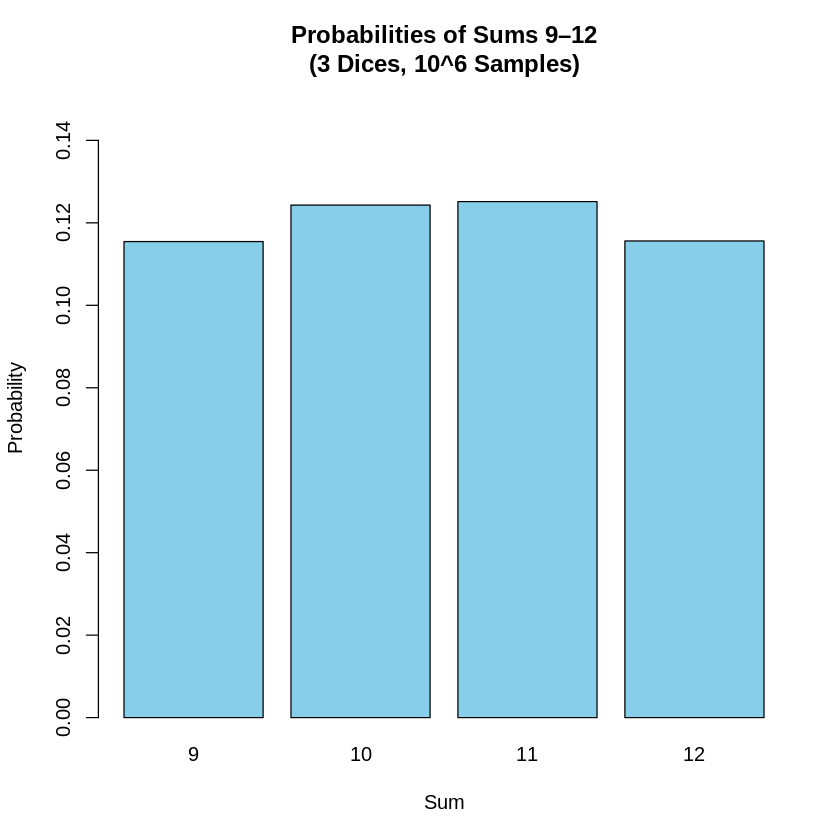

In [ ]:
plot_probabilities <- function(names, probs) {
  # This function takes a list of labels and their corresponding probabilities
  # and creates a bar chart.
  #TODO###########################################################
  barplot(
    height     = probs,
    names.arg  = names,
    col        = "skyblue",
    main       = "Probabilities of Sums 9–12\n(3 Dices, 10^6 Samples)",
    xlab       = "Sum",
    ylab       = "Probability",
    ylim       = c(0, max(probs) * 1.2)
  )
  ################################################################
}
#TODO: plot the probabilities for sample size of 10^6 in results df
##################################################################
row_1e6   <- results[results$sample_size == 1e6, ]
labels    <- c("9", "10", "11", "12")
probs_1e6 <- as.numeric(row_1e6[, c("P9", "P10", "P11", "P12")])
plot_probabilities(labels, probs_1e6)

##################################################################

- What do you see? Was ignoring count of permutations in the beginning correct or there is problem with the experiment?

    Answer: نادیده گرفتن ترتیب ظاهر شدن تاس ها باعث میشود همه آنها هم احتمال شوند در صورتی که اینگونه نیست. برای مثال پیشامد (2,3,4) دارای 6 جایگشت است ولی پیشامد (3,3,3) تنها یک جایگشت دارد

- Why doesn't classical definition of probability doesn't apply here?

    Answer: زمانی میتوان از تعریف کلاسیک احتمال استفاده کرد که تمام نقاط فضای نمونه هم احتمال باشند در صورتیکه در اینجا اینگونه نیست و نقاط فضای نمونه دارای تعداد ترتیب ها و در نتیجه احتمالات متفاوتی هستند

### Showing the correct value(15 pts)


Calculate the exact probability of the sum of three dice being 9 and 10 (you don’t need to show the detailed calculations in the notebook).

Use a line plot to demonstrate that, as the number of experiments increases, the relative frequencies converge to the calculated probabilities.

Add a horizontal line to indicate the calculated probability in the plot.

Use a logarithmic scale for the sample sizes on the chart.

In [ ]:
sample_sizes <- c(seq(100,1000,200), seq(1000,10000,2000), seq(10000,100000,
20000), seq(100000,1000000,200000))
#TODO: Calculate probabilities for different sample sizes.#######

results_sim <- data.frame(
  sample_size = sample_sizes,
  p9  = NA_real_,
  p10 = NA_real_
)

for (i in seq_along(sample_sizes)) {
  k <- sample_sizes[i]
  sims <- sum_of_n_dices(3, k)
  freq <- table(factor(sims, levels = 3:18))
  results_sim$p9[i]  <- as.numeric(freq["9"]  / k)
  results_sim$p10[i] <- as.numeric(freq["10"] / k)
}
results_sim$sample_size <- as.integer(sample_sizes)
print(results_sim)
##############################################################

   sample_size         p9       p10
1          100 0.12000000 0.1200000
2          300 0.09333333 0.1533333
3          500 0.14000000 0.1080000
4          700 0.13857143 0.1357143
5          900 0.10777778 0.1244444
6         1000 0.11500000 0.1340000
7         3000 0.11800000 0.1216667
8         5000 0.12220000 0.1238000
9         7000 0.10971429 0.1255714
10        9000 0.11500000 0.1220000
11       10000 0.11620000 0.1271000
12       30000 0.11710000 0.1264000
13       50000 0.11464000 0.1255800
14       70000 0.11512857 0.1263571
15       90000 0.11491111 0.1266333
16      100000 0.11770000 0.1237900
17      300000 0.11543333 0.1245300
18      500000 0.11577200 0.1257360
19      700000 0.11568857 0.1244757
20      900000 0.11605444 0.1247878


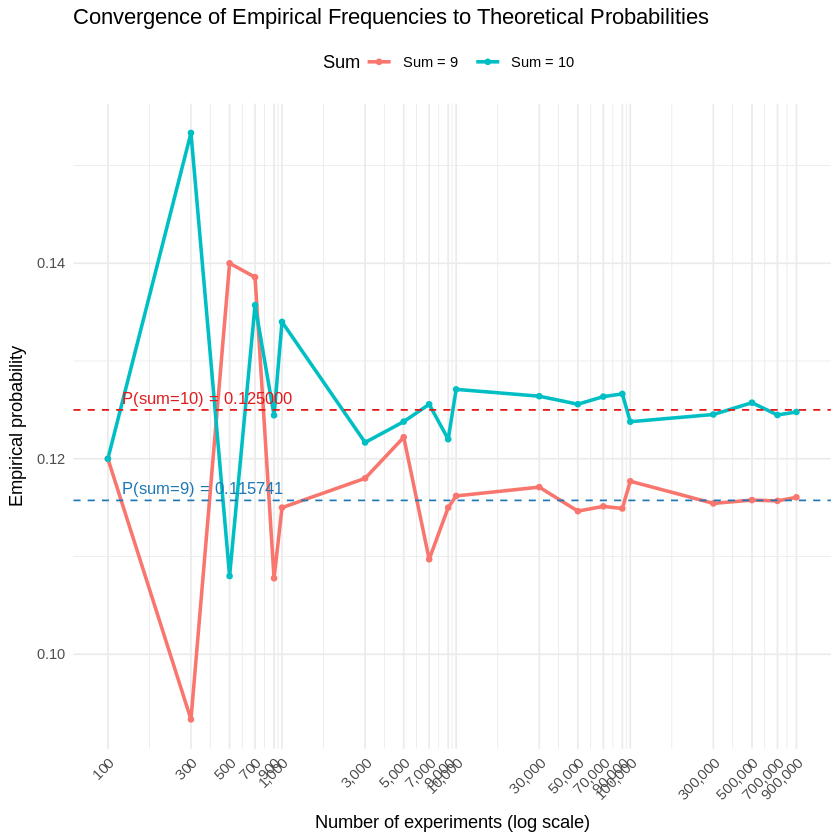

In [ ]:
#TODO: Create a line chart based on probabilities in the previous cell.
##################################################################
library(ggplot2)
library(tidyr)

if (!exists("results_sim")) {
  stop("Data frame 'results_sim' not found. Please run the previous cell to generate it.")
}

p9_theoretical  <- 25/216
p10_theoretical <- 27/216

df_long <- pivot_longer(
  results_sim,
  cols = c("p9", "p10"),
  names_to = "sum_label",
  values_to = "empirical_prob"
)
df_long$sum_label <- factor(df_long$sum_label,
                            levels = c("p9", "p10"),
                            labels = c("Sum = 9", "Sum = 10"))

ggplot(df_long, aes(x = sample_size, y = empirical_prob, color = sum_label)) +
  geom_line(linewidth = 1) +
  geom_point(size = 1.2) +
  scale_x_log10(breaks = unique(results_sim$sample_size),
                labels = scales::comma_format(accuracy = 1)) +
  geom_hline(yintercept = p9_theoretical,  linetype = "dashed", color = "#1f78b4") +
  geom_hline(yintercept = p10_theoretical, linetype = "dashed", color = "#e31a1c") +
  annotate("text", x = min(results_sim$sample_size) * 1.2, y = p9_theoretical,
           label = sprintf("P(sum=9) = %.6f", p9_theoretical),
           color = "#1f78b4", hjust = 0, vjust = -0.5, size = 3.5) +
  annotate("text", x = min(results_sim$sample_size) * 1.2, y = p10_theoretical,
           label = sprintf("P(sum=10) = %.6f", p10_theoretical),
           color = "#e31a1c", hjust = 0, vjust = -0.5, size = 3.5) +
  labs(
    title = "Convergence of Empirical Frequencies to Theoretical Probabilities",
    x = "Number of experiments (log scale)",
    y = "Empirical probability",
    color = "Sum"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "top"
  )
##################################################################

### Increasing Number of Dices(10 pts)
Here, we analyze the distribution of dice sums and observe how it evolves with an increasing number of dice.

In [ ]:
plot_distribution_of_sum_of_n_dices <- function(n, k) {
  # This function simulates rolling n dice for k experiments and plots the
  # resulting probability distribution of their sums using a bar chart.
  #TODO#########################################################
  sims <- replicate(k, sum(sample(1:6, size = n, replace = TRUE)))

  sums_range <- seq(n, 6 * n)
  freq <- table(factor(sims, levels = sums_range))
  probs <- as.numeric(freq) / k
  df <- data.frame(
    sum = sums_range,
    probability = probs
  )

  if (!requireNamespace("ggplot2", quietly = TRUE)) {
    stop("Package 'ggplot2' required but not installed.")
  }
  library(ggplot2)

  p <- ggplot(df, aes(x = sum, y = probability)) +
    geom_col(fill = "steelblue", width = 0.8) +
    scale_x_continuous(breaks = sums_range) +
    labs(
      title = paste0("Distribution of sum of ", n, " dice (", format(k, scientific = FALSE), " trials)"),
      x = "Sum",
      y = "Empirical probability"
    ) +
    theme_minimal() +
    theme(panel.grid.major.x = element_blank(),
          axis.text.x = element_text(angle = 45, hjust = 1))

  print(p)

  invisible(df)
}

Call `plot_distribution_of_sum_of_n_dices` with different dice counts and 10⁵ experiments.

Plotting distribution for n = 3 (100000 trials)

Plotting distribution for n = 5 (100000 trials)



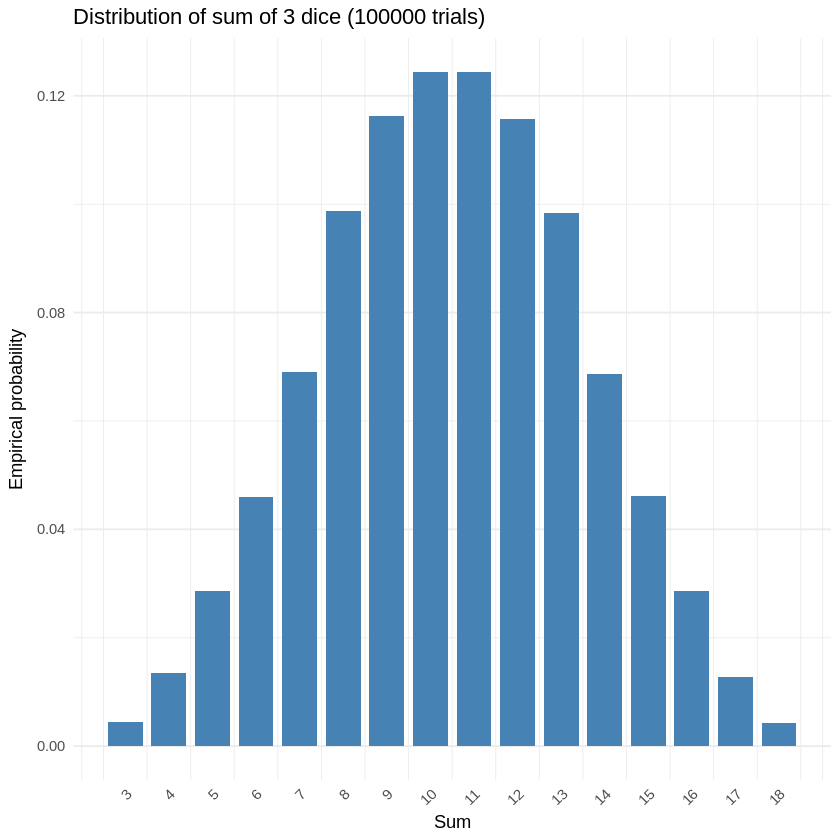

Plotting distribution for n = 10 (100000 trials)



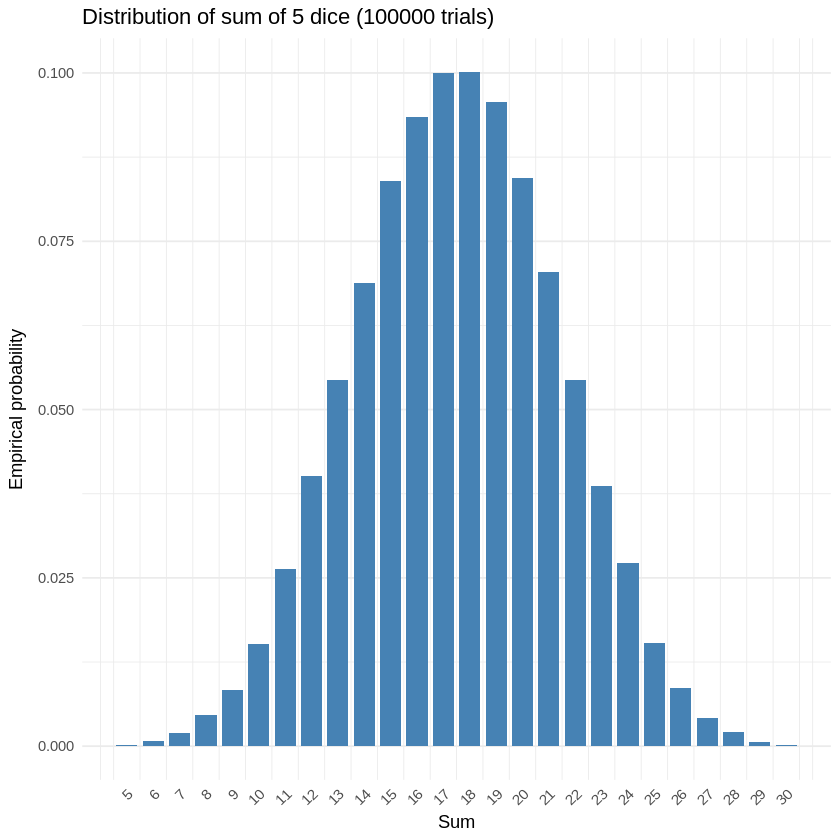

Plotting distribution for n = 15 (100000 trials)



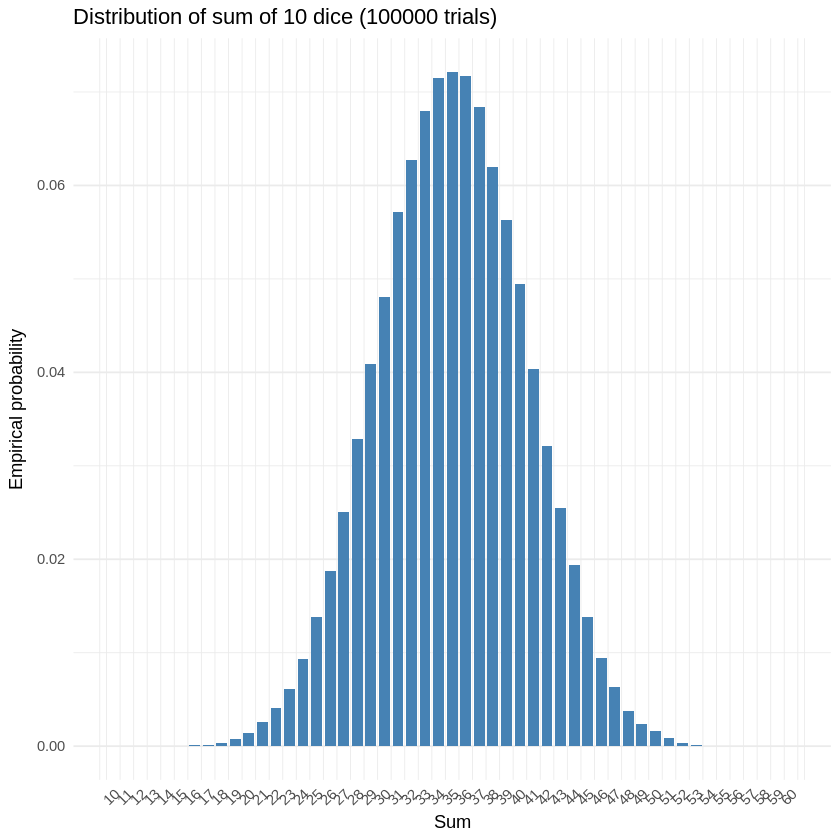

Plotting distribution for n = 20 (100000 trials)



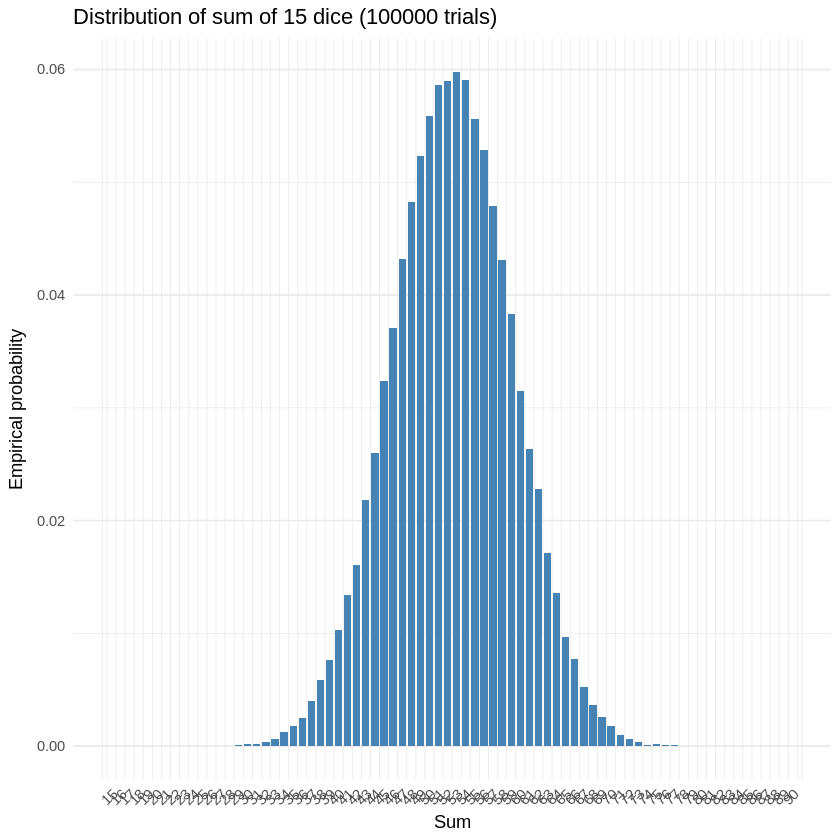

Plotting distribution for n = 50 (100000 trials)



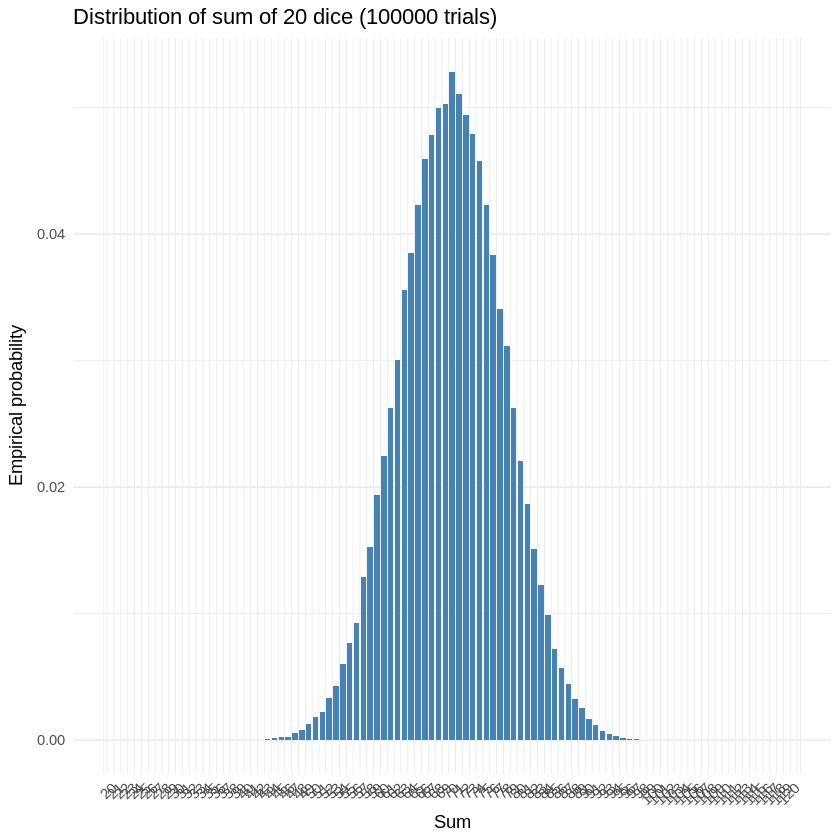

Plotting distribution for n = 100 (100000 trials)



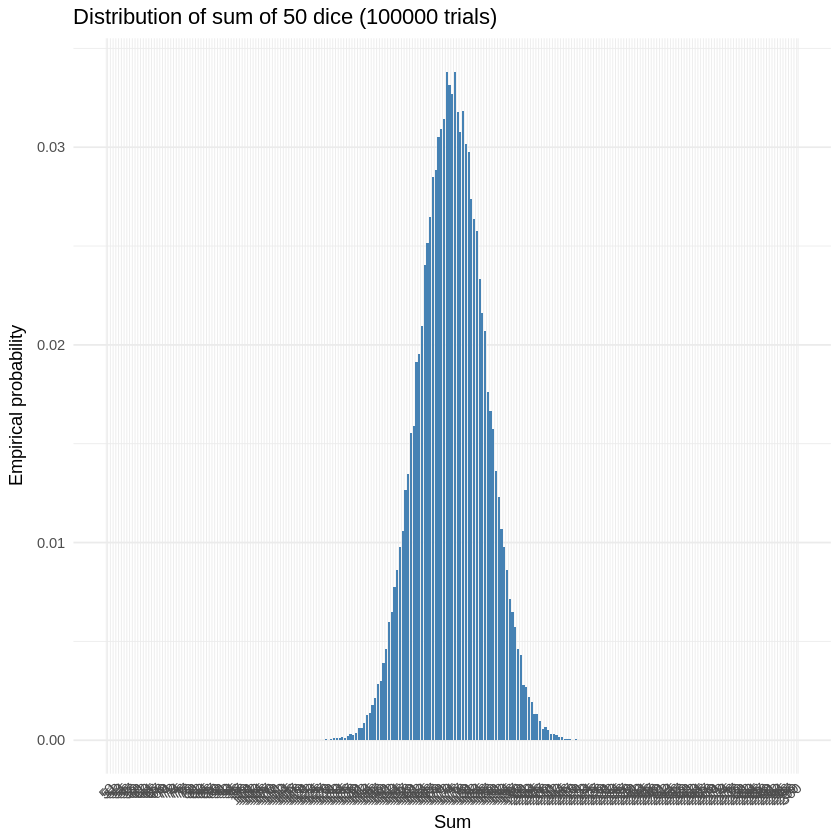

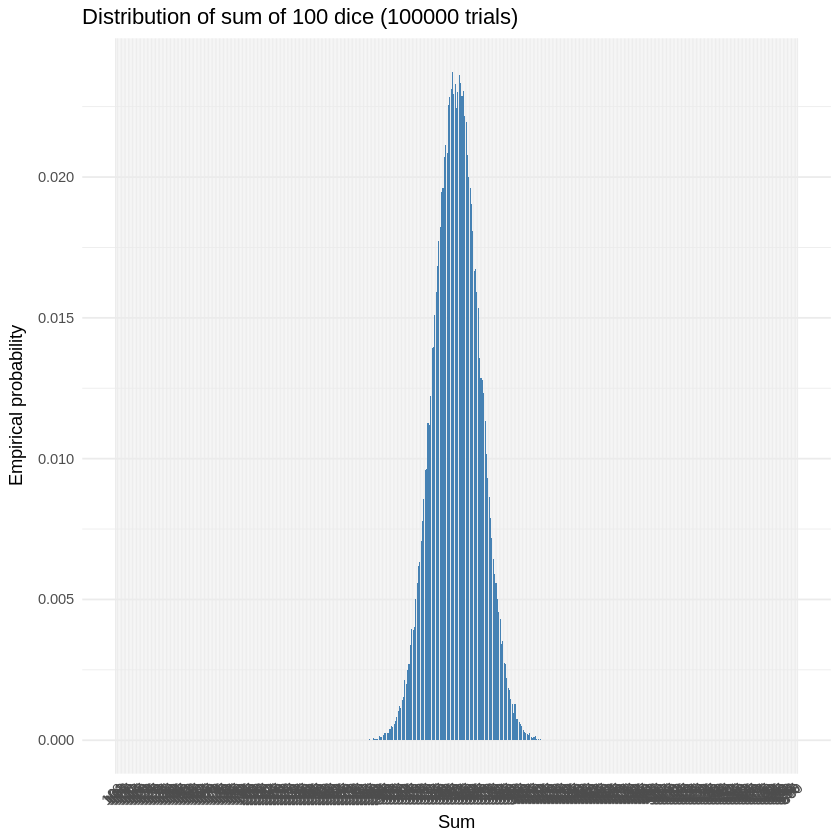

In [ ]:
dice_counts <- c(3,5,10,15,20,50,100)
k <- 1e5
for (n in dice_counts) {
  message("Plotting distribution for n = ", n, " (", format(k, scientific = FALSE), " trials)")
  plot_distribution_of_sum_of_n_dices(n, k)
}

# Problem 2: New class order(40 pts)


In this question you will see that some probability problems are very hard to solve by theory, but become much easier if you use sampling and the frequentist interpretation of probability.


In a university classroom, n students are sitting in a row. After the class ends, they all go outside for a break. When they return, they decide to sit again on the same row, but this time they each choose a seat at random, resulting in a uniform random permutation of the seating order.

Since every pair of neighbors had an argument during the first class and now hate each other, the students want to know:

What is the probability that, in the new seating, There exists two students that sit next to someone they were seated next to in the original arrangement?


### Step 1: Simulate a random sitting order(5 pts)


In [ ]:
random_sitting_order <- function(n){
#TODO: n = number of students.#########################
  sample(1:n, size=n, replace=FALSE)
}

### Step 2: create a new permutation and find if there are similar neighbors(10 pts)


Suppose students are initially seated in order from 1 to n. In the next arrangement, they are placed in a new random order. Determine whether any two neighbors from the original order remain neighbors in the new order.

In [ ]:
has_similar_neighbors <- function(students_count){
  # This function generates a new order of students and return true if two
  # neighbors also appeared in the original order.
  #TODO###########################################################
  n <- as.integer(students_count)
  original <- 1:n
  new_order <- sample(original, size=n, replace=FALSE)
  pos <- match(original, new_order)
  any(abs(pos[-n] - pos[-1]) == 1)
}

### Step3: Conduct the experiment N times(5 pts)


Here you should:
- Conduct the experiment N times.
- See how many times there are similar neighbors
- Calculate probability using frequency definition and return it.

In [ ]:
similar_neighbors_probability <- function(N, students_count){
  #TODO##########################################################
  N <- as.integer(N)
  n <- as.integer(students_count)

  successes <- sum(replicate(N, has_similar_neighbors(n)))
  successes / N
}

### Step 4:(10 pts)
Conduct the experiment for these sample sizes with 5 students.

Print the probabilities for each sample size.

In [ ]:

sample_sizes <-  c(seq(100,1000,200), seq(1000,10000,2000), seq(10000,100000,20000), seq(100000,1000000,200000))
#TODO#############################################################
sample_sizes <- unique(sample_sizes)
sample_sizes <- sort(sample_sizes)

students_count <- 5
set.seed(42)

results <- data.frame(
  sample_size = sample_sizes,
  probability = NA_real_
)

for (i in seq_along(sample_sizes)) {
  results$probability[i] <- similar_neighbors_probability(sample_sizes[i], students_count)
}

results$sample_size <- as.integer(sample_sizes)
print(results)

   sample_size probability
1          100   0.8600000
2          300   0.8733333
3          500   0.8820000
4          700   0.8814286
5          900   0.8933333
6         1000   0.8930000
7         3000   0.8796667
8         5000   0.8792000
9         7000   0.8901429
10        9000   0.8847778
11       10000   0.8822000
12       30000   0.8831333
13       50000   0.8821400
14       70000   0.8834429
15       90000   0.8848889
16      100000   0.8830900
17      300000   0.8832933
18      500000   0.8832360
19      700000   0.8836514
20      900000   0.8830278


Show the probabilities in the You calculated in a line chart.

Use log scale for sample sizes.

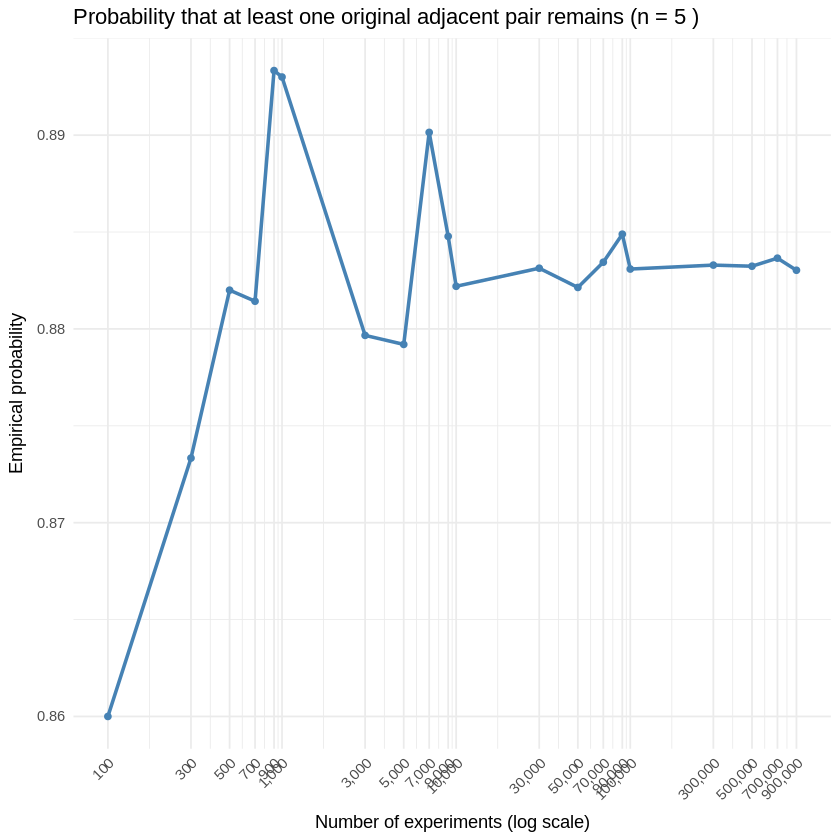

In [ ]:
#TODO#############################################################
library(ggplot2)
library(tidyr)
ggplot(results, aes(x = sample_size, y = probability)) +
  geom_line(linewidth = 1, color = "steelblue") +
  geom_point(color = "steelblue", size = 1.5) +
  scale_x_log10(breaks = results$sample_size, labels = scales::comma_format(accuracy = 1)) +
  labs(
    title = paste("Probability that at least one original adjacent pair remains (n =", students_count, ")"),
    x = "Number of experiments (log scale)",
    y = "Empirical probability"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

### Step 5:(10 pts)
In this step, we want to examine the effect of increasing the number of students on the probability.

Calculate the probability that two students sit next to each other again, using a sample size of $10^6$, for 3 to 20 students.

Display the results in a line chart.

    n     prob
1   3 1.000000
2   4 0.916515
3   5 0.883516
4   6 0.874973
5   7 0.871841
6   8 0.869857
7   9 0.868588
8  10 0.867918
9  11 0.867414
10 12 0.867034
11 13 0.866361
12 14 0.866612
13 15 0.865830
14 16 0.865781
15 17 0.865926
16 18 0.865307
17 19 0.865440
18 20 0.865508


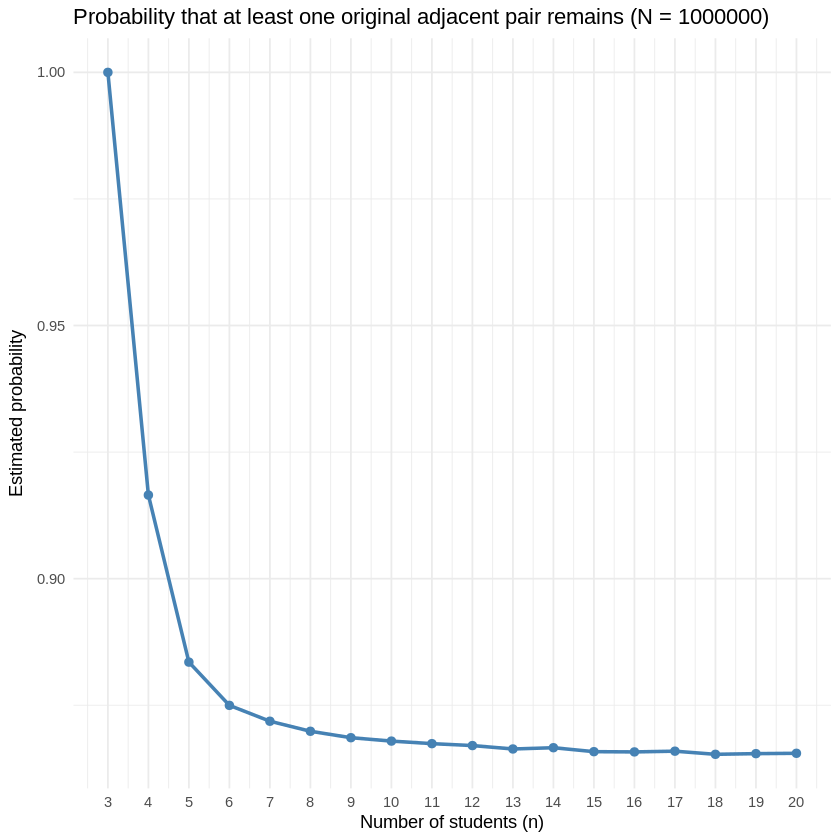

In [23]:
#TODO#############################################################
library(ggplot2)

set.seed(42)

Nsim <- 1e6
n_values <- 3:20

results <- data.frame(
  n = n_values,
  prob = vapply(n_values, function(n) similar_neighbors_probability(Nsim, n), numeric(1))
)

print(results)

ggplot(results, aes(x = n, y = prob)) +
  geom_line(color = "steelblue", linewidth = 1) +
  geom_point(color = "steelblue", size = 2) +
  scale_x_continuous(breaks = n_values) +
  labs(
    title = paste0("Probability that at least one original adjacent pair remains (N = ", format(Nsim, scientific = FALSE), ")"),
    x = "Number of students (n)",
    y = "Estimated probability"
  ) +
  theme_minimal()


Now you can see the theoretical way to solve this question using inclusion-exclusion principle.
(Reading part is optional and This part is meant to show you that in some problems sampling is much easier.)

We assume that the initial order of seating is $A, B, C, D$.

We define a function $T(XY)$ that indicates the number of arrangements in which $X$ and $Y$ are seated next to each other.

We know that the total number of arrangements is $5!$. Now, we can determine the number of undesirable cases using Inclusion-Exclusion principle.
$$
\big(|T(AB)| + |T(BC)| + |T(CD)| + |T(DE)|\big)
- \big(|T(AB) \cap T(BC)| + |T(AB) \cap T(CD)| + |T(AB) \cap T(DE)| + \cdots \big) + \cdots
$$

In the above expression, each sentence cannot be calculated separately.
$$|T(AB)| = |T(BC)| = |T(CD)| = |T(DE)| = 2 \times 4! = 48$$


In the case of invalid sequences, we have 4 sequences in the form
$(|T(XY)|)$.

Therefore, in total we will have:
$ 48 \times 4 = 192 $ undesirable elements.

$$|T(AB) \cap T(BC)| = |T(BC) \cap T(CD)| = |T(CD) \cap T(DE)| = 2 \times 3! = 12$$

The expression $T(BC) \cap T(AB)$ represents the set of sequences in which $A$ and $B$ are adjacent, and $B$ and $C$ are also adjacent.
In the case of invalid sequences, we have 3 sequences in this form; thus, in total we will have:  $12 \times 3 = 36 $

$$|T(AB) \cap T(CD)| = |T(AB) \cap T(DE)| = |T(BC) \cap T(DE)| = 2^2 \times 3! = 24$$

The expression $T(AB) \cap T(CD)$ represents the set of sequences in which $A$ and $B$ are adjacent, and $C$ and $D$ are also adjacent.
In the case of invalid sequences, we have 3 sequences in this form; thus, in total we will have:  $24 \times 3 = 72 $

$$|T(AB) \cap T(BC) \cap T(CD)| =$$
$$|T(BC) \cap T(CD) \cap T(DE)| = 2 \times 2! = 4$$


The expression $T(AB) \cap T(BC) \cap T(CD)$ represents the set of sequences in which $A$, $B$, $C$ and $D$ are adjacent.
In the case of invalid sequences, we have 2 sequences in this form; thus, in total we will have:  $2 \times 4 = 8 $

$$|T(AB) \cap T(BC) \cap T(DE)| =$$
$$|T(AB) \cap T(CD) \cap T(DE)| = 2^2 \times 2! = 8$$


The expression $T(AB) \cap T(BC) \cap T(DE)$ represents the set of sequences in which $A$, $B$ and $C$  are adjacent, and $D$ and $E$ are also adjacent.
In the case of invalid sequences, we have 2 sequences in this form; thus, in total we will have:  $2 \times 8 = 16 $


$$|T(AB) \cap T(BC) \cap T(CD) \cap T(DE)| = $$ $$2 \times 1! = 2$$

The expression $T(AB) \cap T(BC) \cap T(CD) \cap T(DE)$ represents a set of arrangements
in which each individual is next to individuals who were next to them in previous arrangements.
This set has only two members.

Therefore all invalid sequences will be:
$$192-(36+72)+(8+16)-2 = 106$$

And valid sequences will be:

$$5!-106 = 14 $$
And the desired probability(probability of each person sitting next to a new person):
$$\frac{14}{5!} = 0.116667$$
The probability that there exists a pair sitting next to each other again is:
$$ 1- \frac{14}{5!} = 0.8833 $$
Does this match with your observation?
